# Procedural train assembly

An original parametric-geometry exercise inspired by **Procedural Train Assemblies**, credited to Tom Krcha in the Awesome GPT-6 Astra catalog.

Sources: [original creator post](https://x.com/tomkrcha/status/2096082580554777041) · [Awesome GPT-6 Astra](https://github.com/magiccreator-ai/awesome-gpt-6-astra#procedural-train-assemblies)

> The cited project uses TypeScript and Three.js. This notebook instead demonstrates the procedural assembly concept with simple Matplotlib geometry.


## Look → predict → run
**Learn:** one local component can be repeated through coordinate transforms.
**Predict:** does an exploded view change component dimensions or only their placement?
The drawing uses model units. Compare the existing plan with the 3D assembly below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks, COLORS
style()


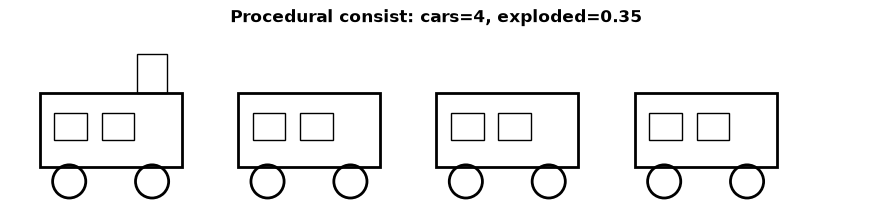

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

def draw_train(cars=3, exploded=0.0):
    fig, ax = plt.subplots(figsize=(11,4))
    x = 0.5
    for car in range(cars):
        gap = car * exploded
        body_x = x + car*3.0 + gap
        ax.add_patch(Rectangle((body_x,1.1),2.4,1.25,fill=False,linewidth=2))
        ax.add_patch(Rectangle((body_x+.25,1.55),.55,.45,fill=False))
        ax.add_patch(Rectangle((body_x+1.05,1.55),.55,.45,fill=False))
        for wx in (body_x+.5, body_x+1.9):
            ax.add_patch(Circle((wx,.85),.28,fill=False,linewidth=2))
        if car == 0:
            ax.add_patch(Rectangle((body_x+1.65,2.35),.5,.65,fill=False))
    ax.set_aspect('equal')
    ax.set_xlim(0, cars*(3+exploded)+1); ax.set_ylim(.3,3.4)
    ax.axis('off'); ax.set_title(f'Procedural consist: cars={cars}, exploded={exploded}')
    plt.show()

draw_train(cars=4, exploded=.35)


## Why procedural?
The number of cars and exploded-view spacing are parameters rather than hand-positioned drawings. The same pattern scales to wheels, bogies, couplers, and animation transforms.


## Extrude and assemble
The side view helps count components. The 3D view reveals width and placement.
Each body is a box in local coordinates translated along the train's x axis.


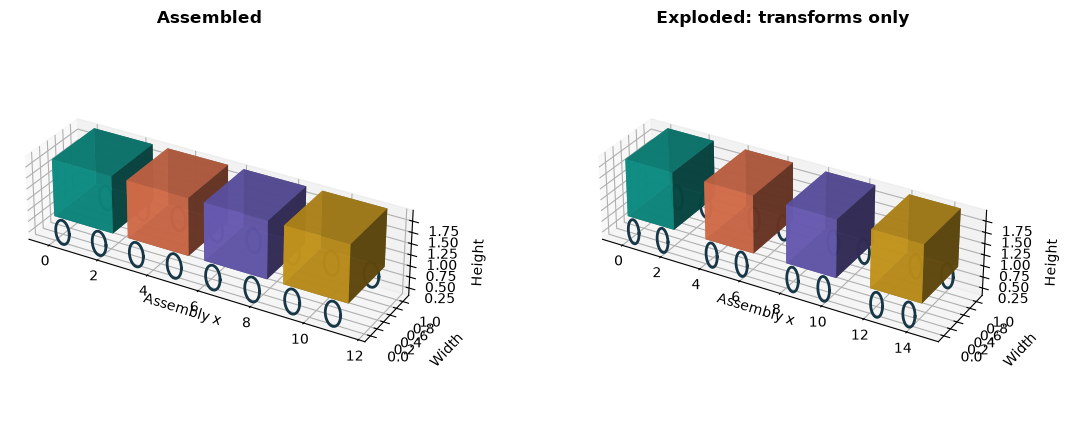

In [3]:
import numpy as np
fig = plt.figure(figsize=(12,4.5))
for panel,gap in enumerate([0.0,1.0],start=1):
    ax=fig.add_subplot(1,2,panel,projection='3d')
    for car in range(4):
        x=car*(3+gap)
        ax.bar3d(x,0,.65,2.4,1.1,1.3,color=COLORS[car%len(COLORS)],alpha=.85)
        for wx in [x+.45,x+1.95]:
            for side in [-.08,1.08]:
                theta=np.linspace(0,2*np.pi,30)
                ax.plot(wx+.28*np.cos(theta),np.full_like(theta,side),.4+.28*np.sin(theta),color='#173747',lw=2)
    ax.set(xlabel='Assembly x',ylabel='Width',zlabel='Height',title='Assembled' if gap==0 else 'Exploded: transforms only')
    ax.set_box_aspect((4,1,1))
fig.tight_layout(); plt.show()


**Experiment:** change car length without changing the placement interval. Predict the collision or gap.
Then derive the interval from car length plus coupler spacing. This is the same geometry pattern used
to extrude buildings in notebook 08; local coordinates keep a procedural scene understandable.
